# 🧠 Predicting Student Mental Health Score 🧠

**Problem:** We're predicting a student's `Mental_Health_Score` (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a **regression** problem since the target is a number, not a category.

**Dataset:** `Student_Social_Media_And_Mental_Health_Impact.csv` — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.


## 1. Import Libraries

We're grouping imports by purpose: data handling, visualization, preprocessing, models, evaluation, and saving. Keeping imports grouped like this makes it easy to see at a glance what the notebook is going to do.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset

We load the CSV and take a first look at its shape and the first few rows. This is always the very first step — you can't make any decisions about a dataset until you've actually looked at it.

In [2]:
df = pd.read_csv('dataset/Student Social Media And Mental Health Impact.csv')


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB


In [4]:
df.sample(10)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
1481,21,Male,Denmark,Undergraduate,Facebook,Networking,2.4,116,6.7,2.3,9.4,Low,8.0
3274,22,Male,Mexico,Undergraduate,WhatsApp,Entertainment,6.3,186,1.2,0.8,6.3,Very High,6.1
2442,23,Female,Germany,Graduate,Snapchat,Entertainment,6.2,193,1.9,2.1,5.3,High,5.8
4881,21,Female,Other,Undergraduate,Snapchat,Entertainment,5.0,165,1.6,1.7,6.2,High,6.7
4625,23,Female,Other,Graduate,Instagram,Entertainment,4.4,146,2.6,1.4,6.3,High,6.3
1336,19,Female,USA,Undergraduate,Instagram,Entertainment,6.9,235,1.0,1.0,5.4,Very High,5.0
949,24,Male,Other,Graduate,TikTok,Entertainment,7.8,230,1.0,0.8,5.0,Very High,4.8
2397,22,Female,Australia,Undergraduate,Facebook,Networking,8.1,240,1.2,1.2,5.1,Very High,4.8
4227,23,Female,Other,Graduate,Snapchat,Entertainment,5.6,171,1.4,1.8,6.8,High,6.2
1163,22,Male,Pakistan,Undergraduate,Instagram,Entertainment,4.7,150,3.9,1.4,6.3,High,5.0


In [5]:
df.shape

(5000, 13)

In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [7]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

## 3. Exploratory Data Analysis (EDA)

We'll keep this focused — six plots, each answering one specific question about the data, not a wall of charts for the sake of it.

### 3.1 — Distribution of the target (`Mental_Health_Score`)

Before predicting anything, we need to understand the shape of what we're predicting.

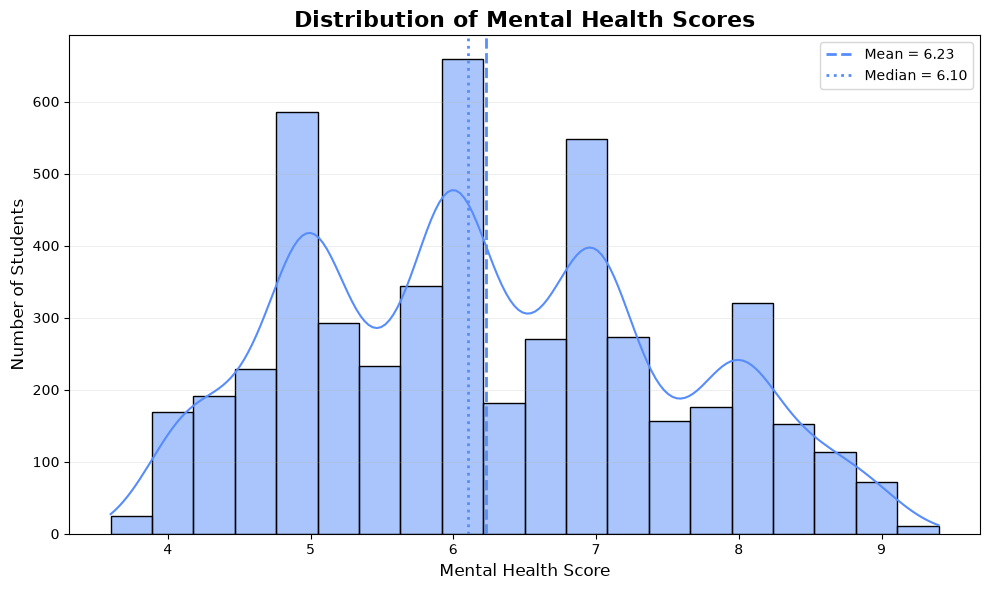

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Mental_Health_Score',
    bins=20,
    kde=True
)

# Mean and median
mean_score = df['Mental_Health_Score'].mean()
median_score = df['Mental_Health_Score'].median()

plt.axvline(
    mean_score,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_score:.2f}'
)

plt.axvline(
    median_score,
    linestyle=':',
    linewidth=2,
    label=f'Median = {median_score:.2f}'
)

plt.title(
    'Distribution of Mental Health Scores',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Mental Health Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### **ANALYSIS**

#### **1. What is the typical mental health score ?**

**Mean = 6.23**

So, the average Mental Health Score of the students is approximately 6.23.

Interpretation: On average, students in this dataset have a mental health score of around 6.23.

#### **2. Where is the middle observation ?**

**Median = 6.10**

This means that approximately:

50% of observations have a score ≤ 6.10
50% have a score ≥ 6.10

Interpretation: The middle Mental Health Score in the dataset is 6.10.

#### **3. Is the distribution approximately symmetric or skewed ?**

The distribution does not appear to be a simple symmetric/normal distribution.

The KDE curve shows several distinct peaks, particularly around approximately:

**5.0**

**6.0**

**7.0**

**8.0**

This suggests that the Mental Health Score distribution is multimodal rather than following a single bell-shaped distribution.

Also, since:

**Mean (6.23) > Median (6.10)**

there is a slight tendency toward right skewness, although the difference is small.

Interpretation: The distribution is multimodal with a slight right-skew tendency, rather than being normally distributed.

#### **4. Where are most students concentrated ?**

The largest concentration of observations appears around the **5.8–6.2** score region, with another substantial concentration around **4.7–5.1** and **6.8–7.1**

The histogram therefore indicates that students' scores are distributed across several ranges rather than being concentrated around only one value.

Interpretation: A substantial number of students have Mental Health Scores around **5–7**, with the highest concentration approximately around **6**.

#### **5. Are mean and median noticeably different ?**

**Measure	- Score**

Mean	- 6.23

Median	- 6.10

Difference	- 0.13

The difference is only 0.13 points, which is relatively small compared with the overall score range.

The two reference lines are therefore quite close together.

**Interpretation:** 

The mean and median are not substantially different, suggesting that extreme values are not causing a large shift in the average. 

However, the multimodal shape shows that the distribution itself is more complex than a normal distribution.

### 3.2 — Correlation heatmap

Which numeric features actually move together with the target?

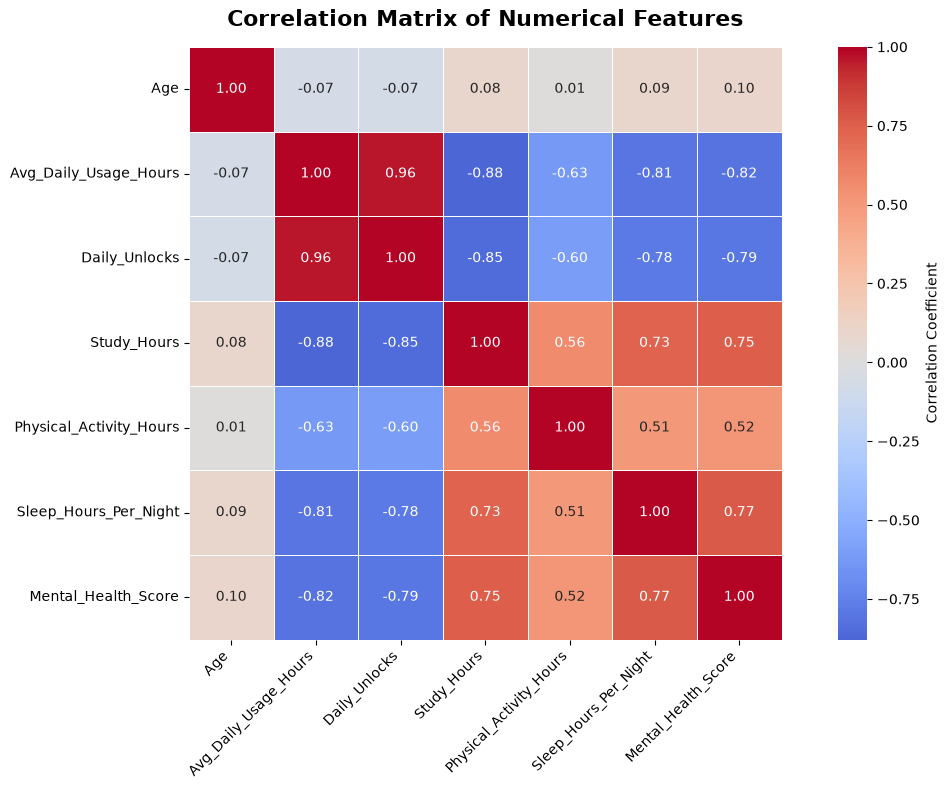

In [10]:
# Select numerical columns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title(
    'Correlation Matrix of Numerical Features',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

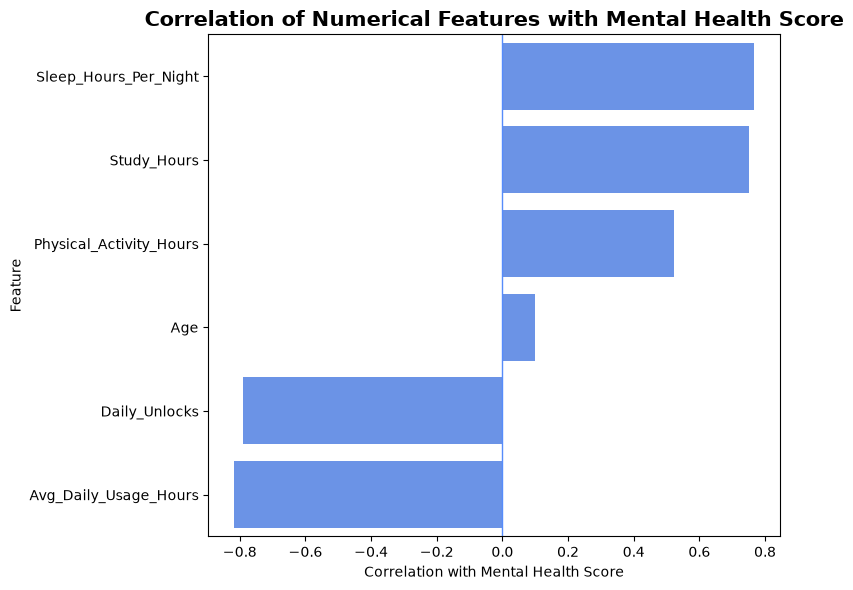

In [11]:
target_corr = (
    df.corr(numeric_only=True)['Mental_Health_Score']
    .drop('Mental_Health_Score')
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)

plt.axvline(0, linewidth=1)

plt.title(
    'Correlation of Numerical Features with Mental Health Score',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Correlation with Mental Health Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### **ANALYSIS**

#### **1. Which numerical feature has the strongest positive relationship with Mental Health Score ?**

Sleep_Hours_Per_Night has the strongest positive correlation:

**r = +0.77**

This indicates a strong positive linear relationship. In this dataset, higher sleep duration is associated with higher Mental Health Scores.

Study_Hours is also strongly positively correlated:

**r = +0.75**

#### **2. Which numerical feature has the strongest negative relationship with Mental Health Score ?**

Avg_Daily_Usage_Hours has the strongest negative correlation:

**r = -0.82**

This indicates a strong negative linear relationship. Higher average daily usage hours are associated with lower Mental Health Scores.

Daily_Unlocks also has a strong negative correlation:

**r = -0.79**

#### **3. What is the relationship between physical activity and Mental Health Score ?**

Physical_Activity_Hours has a correlation of:

**r = +0.52**

This represents a moderate positive relationship.

Students with more physical activity hours tend to have higher Mental Health Scores in this dataset.

#### **4. Does Age have an important linear relationship with Mental Health Score ?**

The correlation between Age and Mental_Health_Score is only:

**r = +0.10**

This is a very weak positive relationship.

Age alone does not appear to have a strong linear association with the Mental Health Score in this dataset.

This doesn't necessarily mean age has no predictive value; correlation only measures a linear relationship between two numerical variables.

#### **5. What does the relationship between Daily Unlocks and Daily Usage Hours tell us ?**

This is one of the strongest relationships in the entire matrix:

**r = +0.96**

This means Daily_Unlocks and Avg_Daily_Usage_Hours are extremely strongly positively correlated.

Students who spend more time using social-media platforms also tend to unlock their devices more frequently.

⚠️ Important ML observation

This very high correlation indicates multicollinearity between these two predictors.

Since both variables also have strong relationships with the target:

**Usage Hours → -0.82**

**Daily Unlocks → -0.79**

we should pay attention to these variables during model development and feature interpretation.

#### **6. What other important relationships exist among the numerical features ?**

There is a clear pattern:

**Feature Relationship --------------- Correlation --------------- Interpretation**

Usage Hours ↔ Daily Unlocks	--------------- **+0.96** --------------- Very strong positive

Usage Hours ↔ Study Hours --------------- **-0.88**	--------------- Very strong negative

Usage Hours ↔ Sleep	--------------- **-0.81** --------------- Strong negative

Usage Hours ↔ Physical Activity	--------------- **-0.63** --------------- Moderate-to-strong negative

Study Hours ↔ Mental Health	 --------------- **+0.75** ---------------  Strong positive

Sleep ↔ Mental Health ---------------  **+0.77** --------------- Strong positive

Physical Activity ↔ Mental Health --------------- **+0.52**	--------------- Moderate positive

This suggests an interesting overall pattern in the dataset: higher daily usage is associated with lower study time, lower physical 

activity, and lower sleep duration, while those lifestyle variables themselves show positive associations with Mental Health Score.

#### **7. What are the most important numerical variables for further analysis ?**

Based only on correlation, the variables that deserve particular attention are:

Avg_Daily_Usage_Hours → -0.82

Daily_Unlocks → -0.79

Sleep_Hours_Per_Night → +0.77

Study_Hours → +0.75

Physical_Activity_Hours → +0.52

Age → +0.10

However, we should not call these the final "most important features" yet. Correlation is not the same as model feature importance, and 

it doesn't capture nonlinear relationships or interactions.

### 3.3 — Stress Level vs Mental Health Score

Does higher stress genuinely come with a lower score?

In [12]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

In [13]:
df['Stress_Level'].unique()

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

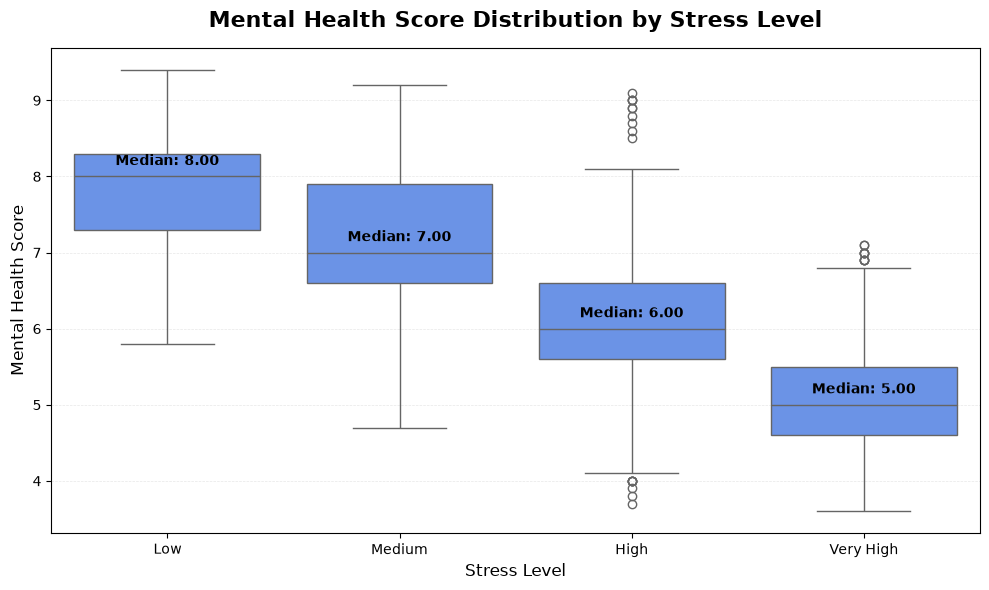

In [14]:
order = ['Low', 'Medium', 'High', 'Very High']

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df,
    x='Stress_Level',
    y='Mental_Health_Score',
    order=order
)

# Add median values above each box
medians = df.groupby('Stress_Level', observed=True)['Mental_Health_Score'].median()

for i, level in enumerate(order):
    if level in medians.index:
        ax.text(
            i,
            medians[level] + 0.15,
            f'Median: {medians[level]:.2f}',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

plt.title(
    'Mental Health Score Distribution by Stress Level',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Stress Level', fontsize=12)
plt.ylabel('Mental Health Score', fontsize=12)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

### **ANALYSIS**

#### 1. Does Mental Health Score change as Stress Level increases ?

Yes, there is a clear downward trend.

As Stress Level increases:

**Low → Medium → High → Very High**

the Mental Health Score generally decreases.

The median falls consistently from **8 → 7 → 6 → 5**

Interpretation: Higher stress levels are associated with lower Mental Health Scores in this dataset.

#### 2. What is the median score for each stress category ?

**Stress Level ---------	Median Mental Health Score**

Low	--------- 8.00

Medium --------- 7.00

High --------- 6.00

Very High --------- 5.00

There is a very clear one-point decrease in the median score as we move from one stress category to the next.

Key observation: The median Mental Health Score decreases systematically as Stress Level increases.

#### 3. How variable are scores within each stress category ?

The box height (IQR) indicates the spread of the middle 50% of scores.

From the chart:

**Low:** Scores are relatively concentrated around **7.3–8.3**

**Medium:** Scores are spread approximately from **6.6–7.9**, showing moderate variability.

**High:** Scores are concentrated approximately around **5.6–6.6**, with some observations extending considerably farther.

**Very High:** Scores are concentrated approximately around **4.6–5.5**, with moderate variability.

**Overall,** the groups have some within-group variation, but their central positions are clearly separated.

#### 4. Are there outliers ?

Yes.

The chart shows several potential outliers:

**Low:** No obvious outliers.

**Medium:** No obvious outliers.

**High:** Several high-score outliers around **8.5–9.1** and several low-score outliers around **3.7–4.0**

**Very High:** Several high-score outliers around **6.9–7.1**

**Interpretation:** The High and Very High stress groups contain several observations that fall unusually far from their respective 

distributions.

These are potential statistical outliers, not necessarily erroneous data points. We should not automatically remove them.

#### 5. Do the distributions overlap substantially between stress groups ?

There is some overlap, but the central distributions are clearly separated.

For example:

Low and Medium have some overlap.

Medium and High have some overlap.

High and Very High also have some overlap.

However, the medians are separated by approximately one point at every stress transition, and the boxes are positioned progressively lower.

**Interpretation:** Although individual Mental Health Scores overlap between adjacent stress categories, the overall distributions show a 

clear separation in their central tendencies.

### 3.4 Most Used Platforms

In [15]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

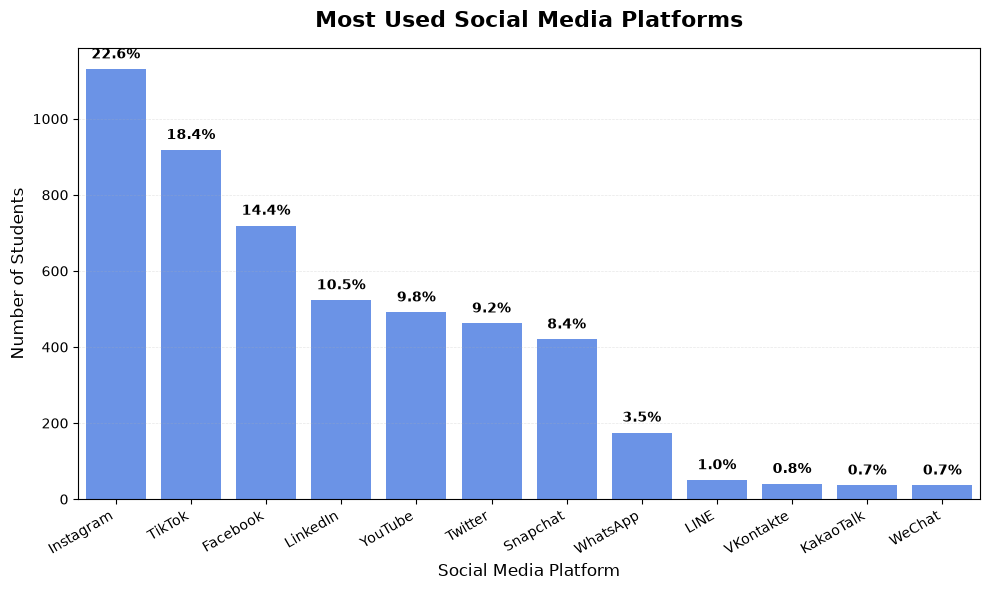

In [20]:
platform_counts = df['Most_Used_Platform'].value_counts()
total = len(df)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=platform_counts.index,
    y=platform_counts.values
)

# Add count + percentage labels
for i, count in enumerate(platform_counts.values):
    percentage = (count / total) * 100

    ax.text(
        i,
        count + 20,
        f'{percentage:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Most Used Social Media Platforms',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Social Media Platform', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

plt.xticks(rotation=30, ha='right')

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

#### **1. Which platform is used by the largest number of students ?**

Instagram is the most commonly used platform.

Students: 1,130

Percentage: 22.6%

Interpretation: Instagram accounts for the largest share of platform usage in the dataset.

#### **2. Which platform is the least commonly used ?**

There is a tie between KakaoTalk and WeChat.

KakaoTalk: 35 students (0.7%)

WeChat: 35 students (0.7%)

Interpretation: KakaoTalk and WeChat are the least commonly used platforms in this dataset.

#### **3. How many students use each platform ?**
**Platform  --------	Students**

Instagram --------	1,130

TikTok	  --------  920

Facebook  --------  720

LinkedIn  --------  525

YouTube	  --------  490

Twitter	  --------  460

Snapchat  --------	420

WhatsApp  --------  175

LINE	  --------  50

VKontakte --------  40

KakaoTalk --------  35

WeChat	  --------  35

Total = 5,000 students

#### **4. What percentage of the dataset uses each platform ?**
**Platform -----	Percentage**

Instagram -----	22.6%

TikTok ----- 18.4%

Facebook ----- 14.4%

LinkedIn ----- 10.5%

YouTube	----- 9.8%

Twitter	----- 9.2%

Snapchat ----- 8.4%

WhatsApp ----- 3.5%

LINE ----- 1.0%

VKontakte ----- 0.8%

KakaoTalk ----- 0.7%

WeChat ----- 0.7%

#### **5. Is platform usage evenly distributed or dominated by a few platforms ?**

Platform usage is not evenly distributed. It is concentrated among a few major platforms.

The three largest platforms are:

Instagram → 22.6%

TikTok → 18.4%

Facebook → 14.4%

Together:

22.6% + 18.4% + 14.4% = 55.4%

So, more than half of all students (55.4%) primarily use these three platforms.

The remaining platforms account for 44.6% collectively, with several platforms having relatively small shares.

### 3.5 Checking Outliers

In [21]:
num_features = df.select_dtypes(include='number')
Q1  = num_features.quantile(0.25)
Q3  = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


### 4. Data Cleaning

Two real issues to fix here — everything else in this dataset is already clean, so we don't manufacture cleaning steps that aren't needed.

In [23]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [24]:
df = df.drop_duplicates()

df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

📌 **Why `clip(lower=0)` and not dropping the row:** the rest of that student's data (age, study hours, stress level, etc.) is still valid and useful — throwing away the whole row over one bad value wastes good data. Clipping caps the impossible value at the nearest realistic one (0 hours) without discarding everything else about that student.

We're not dropping any columns either — every column here has a plausible reason to matter for predicting mental health, and we already confirmed none of them are empty or constant.

### 5. Skewness

**What skewness is:** a measure of how lopsided a numeric column's distribution is. A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, with a long tail.

**Why it matters:** models like Linear Regression assume features are roughly well-behaved. A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction. Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it's worth fixing.

In [25]:
num_cols = df.select_dtypes(include='number')
num_cols.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

### 6. Feature Engineering

**One meaningful engineered feature here:** grouping `Country`.

- `Country` has **111 unique values** in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
- Dropping `Country` entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
- **The fix:** keep the top 10 most frequent countries as their own category, and bucket everything else into `"Other"`. We keep the signal that matters and lose the noise that doesn't.

In [26]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [27]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [28]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [29]:
df['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

📌 **Result:** we went from 111 raw categories down to 11 manageable ones (10 countries + "Other"). This is exactly the kind of decision that separates a project that "just ran `pd.get_dummies()`" from one that actually thought about the data.

### 7. Train-Test Split

**Why we split:** we need data the model has never seen to honestly check how well it generalizes. If we evaluate on the same data we trained on, the model can just "memorize" the answers and look artificially good.

**Common ratios:** 80/20 or 70/30 are both standard. We'll use an 80/20 split here — with 5,000 rows, that still leaves 1,000 rows for a solid, reliable test.

We split **before** fitting any preprocessing — this is the single most common beginner mistake (called data leakage), and we'll avoid it by fitting everything only on the training set.

In [30]:
skwewd_col         = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
# normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use"]


feature_col = skwewd_col + other_numeric_cols + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

### 8. Encoding Strategy

Before we jump into code, let's decide *how* each categorical column should be encoded — this decision matters more than the code itself.

- **`Stress_Level` → Ordinal Encoding.** Its categories have a real, meaningful order: Low < Medium < High < Very High. We already saw in EDA (section 4.3) that the score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.
- **`Gender`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use`, `Country_Grouped` → One-Hot Encoding.** These categories have **no natural order** — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.

We'll implement both of these inside a single `ColumnTransformer` in the next step, rather than doing it manually column by column — that keeps preprocessing consistent and reusable.

### 9. Preprocessing using ColumnTransformer

Our columns need **different treatment**:

- `Study_Hours` (the skewed one) → impute → `log1p` transform → scale
- The other numeric columns → impute → scale (no skew to fix)
- `Stress_Level` → impute → `OrdinalEncoder` with an **explicit order**
- The nominal columns → impute → `OneHotEncoder`

We include a `SimpleImputer` in every branch even though this dataset has zero missing values right now — it's a safety net. Real-world data (and our future API's incoming requests) won't always be this clean, and a pipeline that assumes "no missing values ever" is a pipeline that breaks in production.

`ColumnTransformer` glues all of this into **one object** that applies the right transformation to the right column type in a single `.fit()` / `.transform()` call — no manual column-by-column juggling.

### 10. Build a Pipeline

**Why Pipeline matters:** a `Pipeline` chains preprocessing and the model into a single object. Calling `.fit()` once does both steps in the correct order, and calling `.predict()` on brand-new raw data automatically applies the exact same preprocessing that was used during training — no risk of forgetting a step or applying it inconsistently.

**Why companies prefer this:** when this model gets deployed (which we're doing in Part 2 with FastAPI), the API doesn't need to know *anything* about scaling, encoding, or log transforms — it just loads one saved pipeline object and calls `.predict()` on raw input. That's a huge reduction in what can go wrong in production.

We'll build two pipelines below — one per model — so we can fairly compare them.

In [31]:
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())

])

plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skwewd_col),
    ("Plain_Numeric",plain_numeric_pipeline, other_numeric_cols ),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Normal', nominal_pipeline, normal_col)
])

### 11. Model Building

We're comparing **two models** here because the comparison itself teaches something useful — a plain Linear Regression baseline versus a Random Forest, which can capture the non-linear patterns we spotted back in EDA (section 4.4).

### 11.1 — Baseline: Linear Regression

In [32]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds       = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

Accuracy of Training 0.7135288103911028
Accuracy of Testing 0.7343981609441597
MAE 0.5425443660306423


### 11.2 — Random Forest

Same preprocessor, different model at the end — that's the entire point of building the pipeline once.

In [33]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds          = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")

Accuracy of Training 0.9796011045031185
Accuracy of Testing 0.8665629995872488
MAE : 0.3670732000000001


### 11.3 — Hyperparameter Tuning the Random Forest

When tuning a `Pipeline`, each parameter needs to be prefixed with the step name (`regressor__`) so `RandomizedSearchCV` knows which part of the pipeline it belongs to. We use `RandomizedSearchCV` instead of a full grid search — it samples a fixed number of combinations instead of testing every single one, which is far faster while still finding a strong set of parameters.

In [34]:
param_grid = {
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [35]:
random_search.best_params_

{'random forest__n_estimators': 300,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [36]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.856448550961598
MAE Score for random forest after hyperparameter tuning 0.3843292085362411


### 12. Model Evaluation

**Metrics, explained simply:**
- **R² Score** — how much of the variation in mental health scores our model explains, from 0 (useless) to 1 (perfect). 0.85 means the model explains 85% of the pattern.
- **MAE (Mean Absolute Error)** — on average, how far off our prediction is, in the original units (score points). Easy to explain to a non-technical person.
- **RMSE (Root Mean Squared Error)** — similar to MAE, but penalizes big mistakes more heavily. Useful for spotting whether a model makes a few very wrong predictions.

Cross-validation R² (from tuning, above) tells us how good the model is across many different train/validation splits — the real, honest test is still the untouched test set below.

In [37]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.734398     0.713529  0.542544  0.683006
1  Random Forest (default)  0.866563     0.979601  0.367073  0.484113
2    Random Forest (tuned)  0.856449     0.956629  0.384329  0.502126


### 13. Save the Model

We save the **entire pipeline** — preprocessing and model together — as a single file, not just the raw model. **Why:** if we only saved the Random Forest object, our FastAPI backend would need to manually recreate every encoding and scaling step by hand at prediction time, which is fragile and easy to get wrong. Saving the full pipeline means the backend just loads one file and calls `.predict()` on raw input — the pipeline handles everything internally, exactly the same way it did during training.

In [38]:
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']


### **Next steps (Part 2):**
Build a FastAPI backend with Pydantic request validation that loads `mental_health_pipeline.pkl` and exposes a `/predict` endpoint, then connect a simple frontend, then deploy both so this becomes a live, clickable demo.
